# Progress Proyek

Progress serta next progress terletak di akhir kode

In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")

# print("Path to dataset files:", path)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import pathlib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Deskripsi dataset dari Kaggle:
The dataset contain 35,685 examples of 48x48 pixel gray scale images of faces divided into train and test dataset. Images are categorized based on the emotion shown in the facial expressions (happiness, neutral, sadness, anger, surprise, disgust, fear).

In [4]:
import pandas as pd
from pathlib import Path

data_train = pathlib.Path('emotion-detection-fer/versions/1/train')
data_test = pathlib.Path('emotion-detection-fer/versions/1/test')

paths_train = [path.parts[-2:] for path in Path(data_train).rglob('*.*')] 
paths_test = [path.parts[-2:] for path in Path(data_test).rglob('*.*')] 

df_train = df = pd.DataFrame(data=paths_train, columns=['Class','Images'])
df_test = df = pd.DataFrame(data=paths_test, columns=['Class','Images'])

# Eksplorasi Data

Text(0, 0.5, 'Count Image')

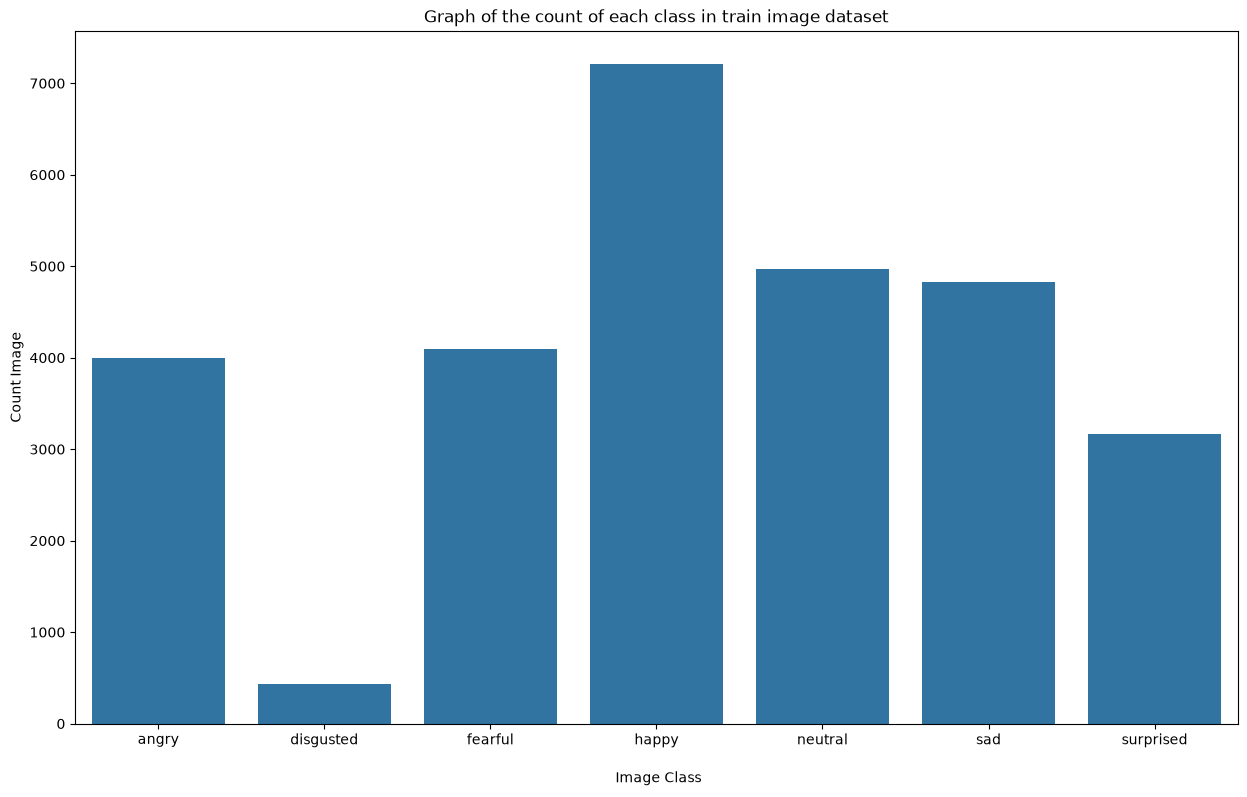

In [5]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(15,9))
sns.countplot(data=df_train, x='Class')
plt.title('Graph of the count of each class in train image dataset')
plt.xlabel('\n Image Class')
plt.ylabel('Count Image')

Text(0, 0.5, 'Count Image')

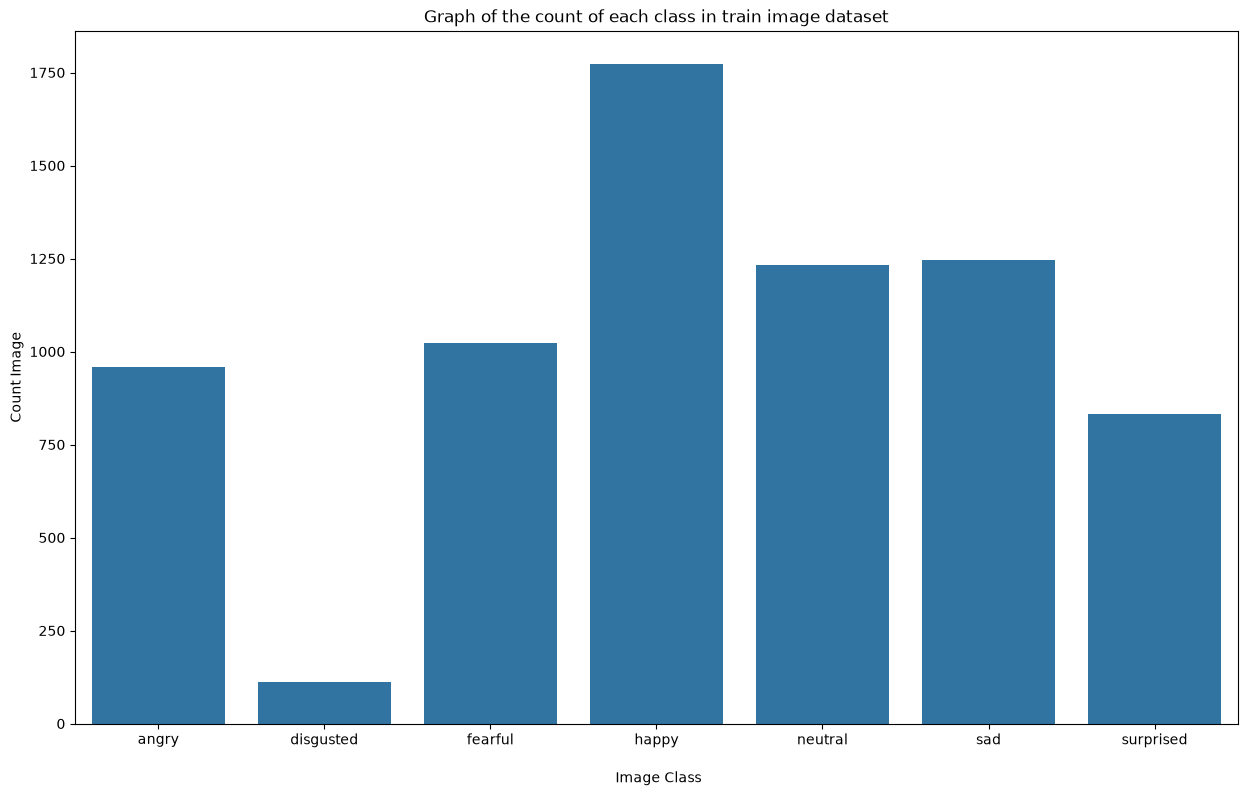

In [6]:
fig, ax = plt.subplots(figsize=(15,9))
sns.countplot(data=df_test, x='Class')
plt.title('Graph of the count of each class in train image dataset')
plt.xlabel('\n Image Class')
plt.ylabel('Count Image')

## Data disgusted tidak bisa di prediksi oleh model dikarenakan data tersebut sangatlah minoritas dibandingkan data yang lain, maka di hapus / dibuat direktori dataset yang tidak memiliki kelas disgusted

In [8]:
import shutil
from pathlib import Path

source_train = Path("emotion-detection-fer/versions/1/train")
destination_train = Path("emotion-detection-fer/train_no_disgust")

destination_train.mkdir(exist_ok=True)

for folder in source_train.iterdir():
    if folder.name == "disgusted":
        continue

    shutil.copytree(folder, destination_train / folder.name, dirs_exist_ok=True)

source_test = Path("emotion-detection-fer/versions/1/test")
destination_test = Path("emotion-detection-fer/test_no_disgust")

destination_train.mkdir(exist_ok=True)

for folder in source_test.iterdir():
    if folder.name == "disgusted":
        continue

    shutil.copytree(folder, destination_test / folder.name, dirs_exist_ok=True)

# Tensorflow dataset from directory/folder

In [10]:
img_size = 48
batch_size = 128

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    destination_train,
    validation_split=0.1, 
    subset="training",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=batch_size)

validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    destination_train,
    validation_split=0.1, 
    subset="validation",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=batch_size)

Found 28273 files belonging to 6 classes.
Using 25446 files for training.
Found 28273 files belonging to 6 classes.
Using 2827 files for validation.


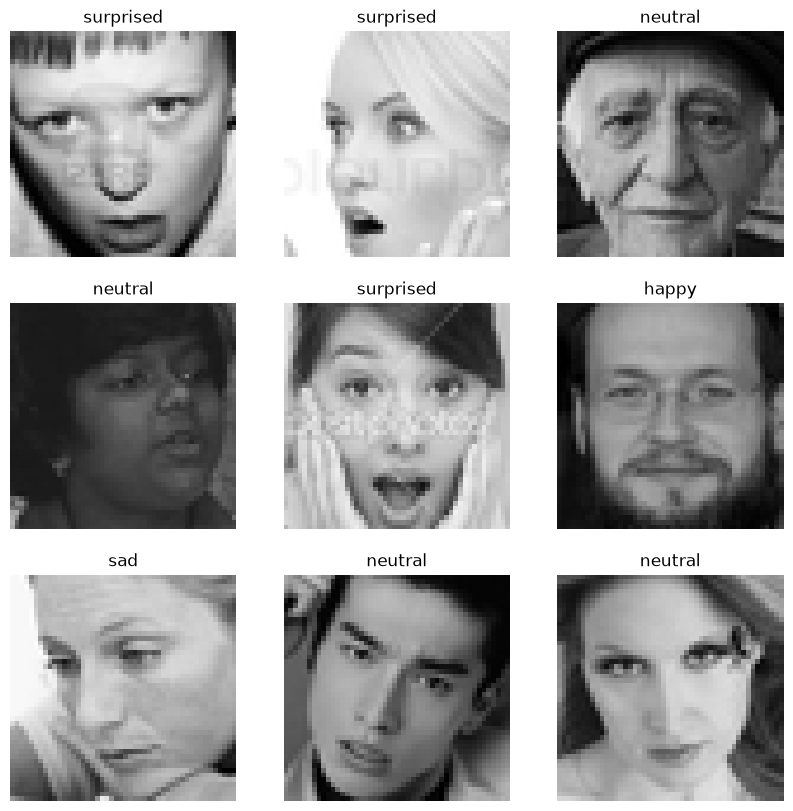

In [11]:
class_names = train_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

# Definisi Model CNN

In [12]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
])

In [13]:
num_classes = 6
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, 3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(32, 3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, 3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(64, 3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.MaxPooling2D(),    
    layers.Dropout(0.35),
    
    layers.Conv2D(128, 3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(128, 3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    
    layers.Dense(num_classes, activation='softmax')    
])

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(optimizer='Adam'
  , loss='sparse_categorical_crossentropy'
  , metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Model Training

In [15]:
epochs=50
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50


199/199 [==============================] - 89s 431ms/step - loss: 1.7390 - accuracy: 0.2574 - val_loss: 2.1279 - val_accuracy: 0.2473 - lr: 0.0010
Epoch 2/50
199/199 [==============================] - 60s 300ms/step - loss: 1.6512 - accuracy: 0.3060 - val_loss: 2.9182 - val_accuracy: 0.2519 - lr: 0.0010
Epoch 3/50
199/199 [==============================] - 62s 309ms/step - loss: 1.5350 - accuracy: 0.3761 - val_loss: 1.6205 - val_accuracy: 0.3537 - lr: 0.0010
Epoch 4/50
199/199 [==============================] - 61s 306ms/step - loss: 1.4255 - accuracy: 0.4300 - val_loss: 1.8447 - val_accuracy: 0.2932 - lr: 0.0010
Epoch 5/50
199/199 [==============================] - 61s 308ms/step - loss: 1.3654 - accuracy: 0.4602 - val_loss: 1.8063 - val_accuracy: 0.3375 - lr: 0.0010
Epoch 6/50
199/199 [==============================] - 61s 307ms/step - loss: 1.3262 - accuracy: 0.4777 - val_loss: 1.5056 - val_accuracy: 0.4018 - lr: 0.0010
Epoch 7/50
199/199 [==============================

# Evaluation

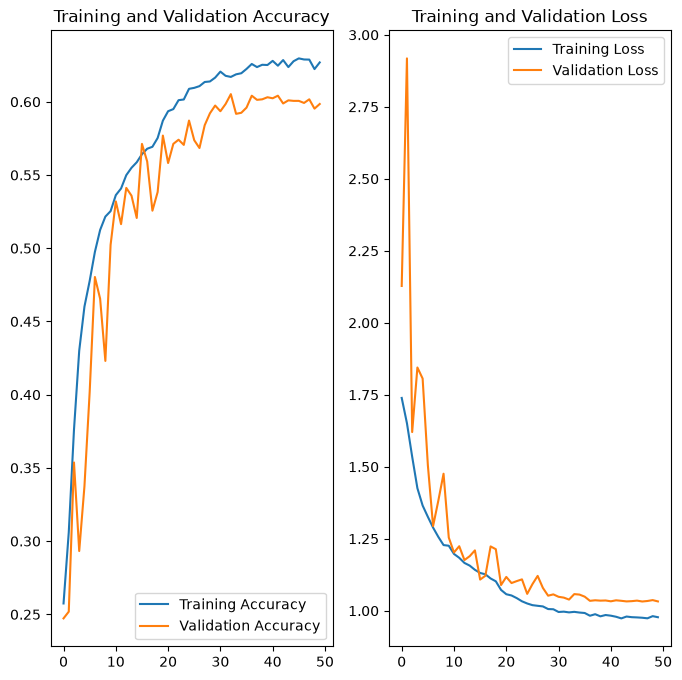

In [16]:
accuracy = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(history.history['accuracy']))
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [17]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    destination_test,
    seed=42,
    image_size=(img_size, img_size),
    batch_size=batch_size)

Found 7067 files belonging to 6 classes.


In [44]:
loss, acc = model.evaluate(test_ds)

print(acc)

56/56 [==============================] - 5s 89ms/step - loss: 0.9989 - accuracy: 0.6147
0.614687979221344


Found 7067 files belonging to 6 classes.
Accuracy from confusion matrix: 0.6146879864157351
              precision    recall  f1-score   support

       angry       0.57      0.48      0.52       958
     fearful       0.46      0.32      0.37      1024
       happy       0.81      0.86      0.84      1774
     neutral       0.51      0.65      0.57      1233
         sad       0.48      0.48      0.48      1247
   surprised       0.72      0.76      0.74       831

    accuracy                           0.61      7067
   macro avg       0.59      0.59      0.59      7067
weighted avg       0.61      0.61      0.61      7067



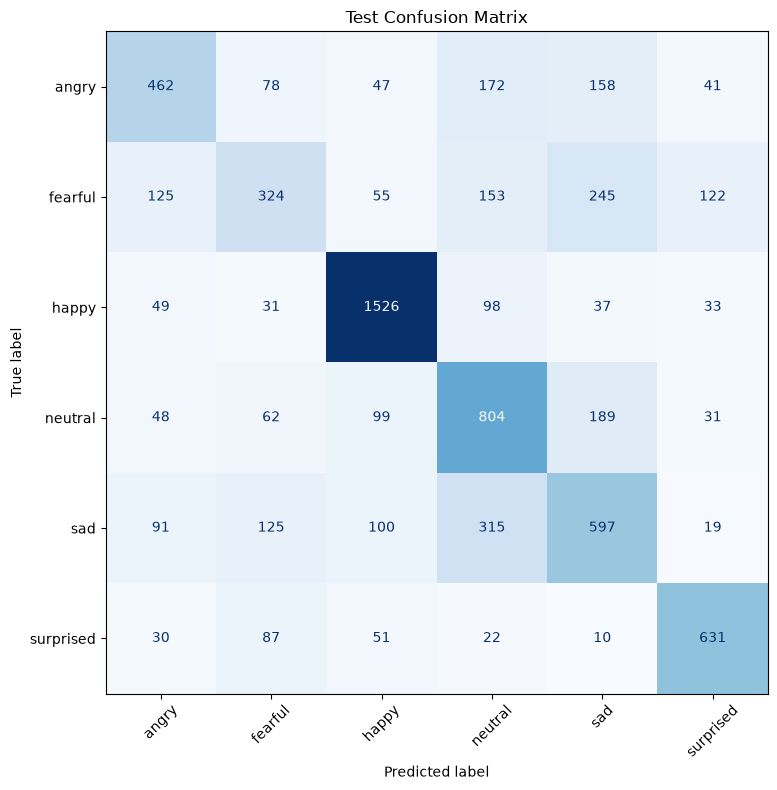

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Ensure deterministic order
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    destination_test,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=False
)

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Accuracy from confusion matrix:",
      np.mean(y_true == y_pred))

print(classification_report(y_true, y_pred, target_names=test_ds.class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_ds.class_names
)

disp.plot(
    cmap='Blues',
    values_format='d',
    ax=plt.gca(),
    colorbar=False
)

plt.title("Test Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sedikit tambahan, ketika mengtraining model saat data 'disgusted' masih belum dihapus. Label itu sama sekali tidak pernah diprediksi

# Simpan Modelnya

In [64]:
model.save("emotion_model")

INFO:tensorflow:Assets written to: emotion_model\assets


INFO:tensorflow:Assets written to: emotion_model\assets


# PROGRESS
Progress proyek ini adalah membuat model CNN untuk deteksi perasaan atau emosi pada manusia. Disini, ada sedikit perubahan yang dilakukan yaitu, menghapus class Disgusted dikarenakan data kelas tersebut sangatlah sedikit sehingga model tersebut sama sekali tidak memprediksi kelas tersebut ketika di training pertama kali, sehingga dihapus.

Model CNN yang dibangun mampu mencapai nilai accuracy sebesar 61% yang cukup baik, dan ketika dibandingkan pada studi literatur seperti https://doi.org/10.48550/arXiv.2105.03588 ; dapat dilihat bahwa hasil model CNN yang dibangun cukup sebanding dengan literatur lain dimana model CNN mereka mampu mencapai 62% dan model dengan akurasi tertinggi menggunakan VGG pada 73%. Namun, dikarenakan proyek ini akan melakukan deteksi emosi secara real time, maka model CNN ini lebih preferable dibandingkan, contohnya VGG, dikarenakan lebih ringan dan memiliki performa yang lebih baik.

# Next Progress
Progress berikutnya adalah merancang real time emotion detection tersebut secara keseluruhan. Menggunakan materi dari pertemuan 10 untuk face detection dan menggabungkan model ini untuk membangun real time emotion detection. Juga akan dieksplor beberapa cara untuk membuat sistem tersebut dapat merespons dengan pengguna baik itu secara manual, atau mungkin menyambungkannya dengan AI